In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict

/home/alex/NuMI/PELEE/


In [2]:
ending = "Jan19b_Data"
ending_nod = "Jan19b"



##  Energy

## Closure Tests

## Blockwise Unfolding

In [5]:

with open('../blockwise/stv-analysis-new/blockwise_unsmeared_events_energy_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
events = content[0:]
    
for i in range(12):
    events[i]=events[i].rstrip().rstrip(',')
    events[i] = float(events[i])
    
print("Unsmeared events")
print(events)
print("")

#------------------------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_AC_energy_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
AC = content[0:]
    
for i in range(144):
    AC[i]=AC[i].rstrip().rstrip(',')
    AC[i] = float(AC[i])
    

chunks = [AC[x:x+12] for x in range(0, len(AC), 12)]

print("AC")
print(chunks)
print("")
#---------------------------------------------------------------

with open('nue_full_500_catsel_nopions_recoE_usingSelection_prior_true_signal_blockwise_recoCut_comb_'+ending_nod+'.csv') as file:
    content = file.readlines()
prior_true = content[0:]
    
for i in range(12):
    prior_true[i]=prior_true[i].rstrip().rstrip(',')
    prior_true[i] = float(prior_true[i])
    
print("Prior Truth: ")
print(prior_true)
print("")

#----------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_errors_energy_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
errs = content[0:]
    
for i in range(12):
    errs[i]=errs[i].rstrip().rstrip(',')
    errs[i] = float(errs[i])
    
print("Errors: ")
print(errs)
print("")
print("################################################################")
print("")

#----------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_cov_matrix_energy_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
cov = content[0:]
    
for i in range(144):
    cov[i]=cov[i].rstrip().rstrip(',')
    cov[i] = float(cov[i])
    

chunks_cov = [cov[x:x+12] for x in range(0, len(cov), 12)]

print("cov")
print(chunks_cov)
print("")


FileNotFoundError: [Errno 2] No such file or directory: '../blockwise/stv-analysis-new/blockwise_unsmeared_events_energy_MC_ONLY_weighted_recoCut_incErr_Jan19b_Data.csv'

In [4]:
with open('../blockwise/stv-analysis-new/blocks_12.txt') as file:
    content = file.readlines()
blocks = content[0:]

print(blocks)

['12\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  1\n', '7  1\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n', '12\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  1\n', '7  1\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n']


In [5]:

made_data_sig = np.dot(prior_true, chunks)
print("Prior_Truth x AC: ")
print(made_data_sig)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(events)
print("")

diff = made_data_sig - events
print("")
print("Difference")
print(diff)

#for i in made_data_sig:
#    print(i)

print("")
diffasfrac = np.nan_to_num(diff/made_data_sig)
print(diffasfrac*100)

Prior_Truth x AC: 
[ 212.11173718  446.01419262  223.89662498  117.46603163   29.45117274
   64.25945379 3494.07386127 9093.0876917  5329.96737712 2478.0292863
  344.71841763  103.93920673]


Unfolding Done with MC Data Signal: 
[533.701, 361.028, 209.781, 97.7483, 36.2442, 31.4206, 3730.46, 7351.36, 5169.95, 1642.41, 221.813, 69.0345]


Difference
[-321.58926282   84.98619262   14.11562498   19.71773163   -6.79302726
   32.83885379 -236.38613873 1741.7276917   160.01737712  835.6192863
  122.90541763   34.90470673]

[-151.61313895   19.05459378    6.30452781   16.78590087  -23.06538799
   51.10353707   -6.76534464   19.15441433    3.00222057   33.7211223
   35.65385873   33.5818483 ]


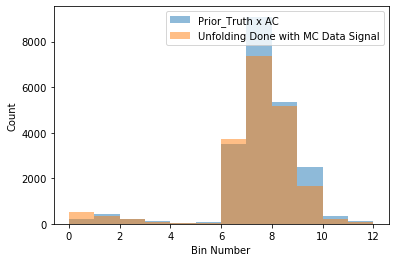

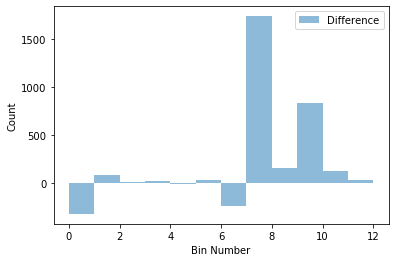

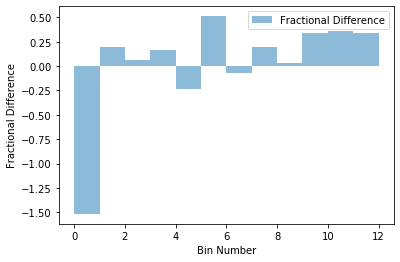

In [6]:
import random
import numpy
from matplotlib import pyplot

bins = np.arange(0, 13, 1)
count = np.arange(0.0, 12.0, 1)

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()

pyplot.hist(count, bins, weights=diff, alpha=0.5, label='Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()


pyplot.hist(count, bins, weights=diffasfrac, alpha=0.5, label='Fractional Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Fractional Difference")
pyplot.show()

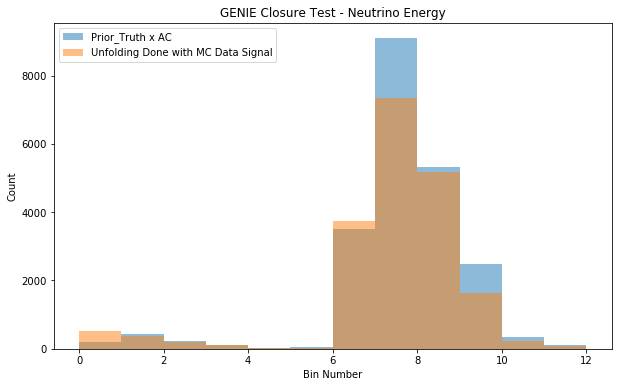

In [7]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper left')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.title("GENIE Closure Test - Neutrino Energy")
pyplot.show()

fig.savefig("Data_closure_test_"+ending+".svg",bbox_inches='tight' )

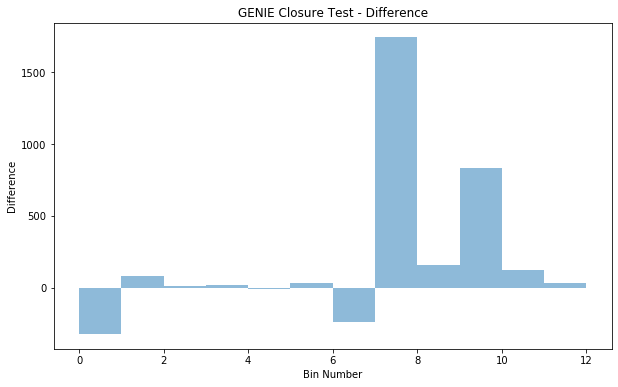

In [8]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=diff, alpha=0.5)
#pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Difference")
pyplot.title("GENIE Closure Test - Difference")
pyplot.show()

fig.savefig("Data_closure_test_diff_"+ending+".svg",bbox_inches='tight' )

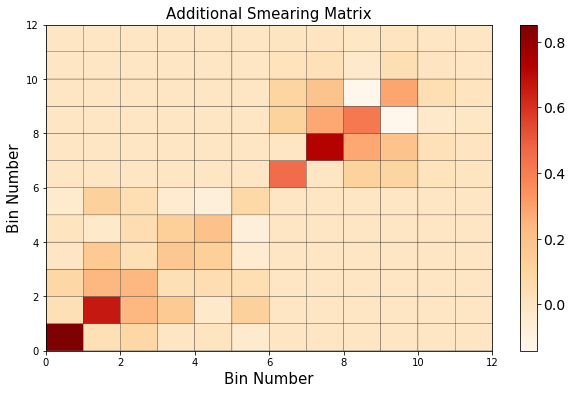

In [9]:
fig = plt.figure(figsize=(10, 6))  
    
plt.pcolor(bins, bins, chunks, cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Additional Smearing Matrix', fontsize=15)

plt.show()

fig.savefig("Data_closure_test_Ac_"+ending+".svg",bbox_inches='tight' )

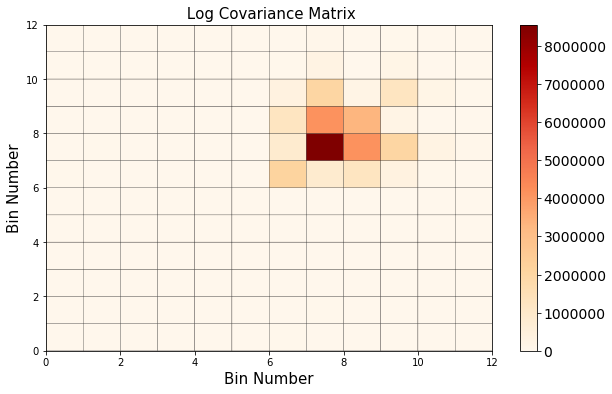

In [10]:
fig = plt.figure(figsize=(10, 6))  

#print(bins)
#bins = np.arange(0, 17, 1)
#count = np.arange(0.0, 16.0, 1)
    
plt.pcolor(bins, bins, (chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

## Need to convert to xsec units

xsec = unfolded event counts / (integrated flux * number of argon targets)

In [11]:
###################
### #N argon target calculation
###################

density = 1.3836  #g/cm^3
volume = (246-10)*(106-(-106))*(1026-10)         #cm^3
NA = 6.022E23   #atoms/mol
Nnuc = 40       #nucleans / atom
mmol = 39.95    #g/mol

Narg = (density * volume * NA * Nnuc)/mmol   #nucleons

print("number of argon targets = ", Narg)

number of argon targets =  4.240685683288815e+31


In [12]:
#Need R1 AND R3

####NUE
POT_R1 = 2.0E20 
int_flux_per_POT_R1 = 1.1864530596659353e-11
POT_R3 = 5.014E20
int_flux_per_POT_R3 = 8.628376225834778e-12

int_flux = (int_flux_per_POT_R1*POT_R1) + (int_flux_per_POT_R3*POT_R3)    #cm^-2

print("Nue integrated flux: ", int_flux)

####NUMU

POT_numu_R1 = 2.0E20 
int_flux_per_POT_numu_R1 = 5.455771063338641e-10
POT_numu_R3 = 5.014E20 
int_flux_per_POT_numu_R3 = 3.6729003479115414e-10

int_flux_numu = (int_flux_per_POT_numu_R1*POT_numu_R1) + (int_flux_per_POT_numu_R3*POT_numu_R3)    #cm^-2

print("Numu integrated flux: ", int_flux_numu)

Nue integrated flux:  6699173958.965427
Numu integrated flux:  293274644711.0575


In [13]:
nue_events = np.array(events[0:6])
numu_events = np.array(events[6:12])

nue_errs = np.array(errs[0:6])
numu_errs = np.array(errs[6:12])

In [14]:
#number of events

xsec_nue_events = nue_events / (int_flux * Narg  * 0.25)     
xsec_numu_events = numu_events / (int_flux_numu * Narg  * 0.25)     


#uncertainty

#xsec_nue_errs = nue_errs / (int_flux * Narg )     
#xsec_numu_errs = numu_errs / (int_flux_numu * Narg )     

In [15]:
#Need the four sections of the cov matrix

blockwise_errs = chunks_cov
#print(blockwise_errs)
#print("")

#NUE ONLY
bot_left = blockwise_errs[:6]
for i in range(len(bot_left)):
    bot_left[i] = bot_left[i][:6]
    
nue_errs_bot = np.array(bot_left)/((int_flux*int_flux)*(Narg*Narg)*(0.25*0.25))
xsec_nue_errs = (np.sqrt(np.diag(nue_errs_bot)))
    
#MIX
bot_right = blockwise_errs[:6]
for i in range(len(bot_right)):
    bot_right[i] = bot_right[i][6:]
    
mix_errs_bot = np.array(bot_right)/((int_flux*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_botmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_bot)))

    
#MIX
top_left = blockwise_errs[6:]
for i in range(len(top_left)):
    top_left[i] = top_left[i][:6]
    
mix_errs_top = np.array(top_left)/((int_flux*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_topmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_top)))

#NUMU ONLY
top_right = blockwise_errs[6:]
for i in range(len(top_right)):
    top_right[i] = top_right[i][6:]
    
numu_errs_top = np.array(top_right)/((int_flux_numu*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_numu_errs = (np.sqrt(np.diag(numu_errs_top)))


/tmp/ipykernel_13569/368598948.py:21: RuntimeWarning: invalid value encountered in sqrt
  xsec_botmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_bot)))
/tmp/ipykernel_13569/368598948.py:30: RuntimeWarning: invalid value encountered in sqrt
  xsec_topmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_top)))


In [16]:
#Put it back together with it's new units

#cov_xsec = np.zeros_like(blockwise_errs)
#print(cov_xec)
print("----------------")

cov_xsec = np.block([[nue_errs_bot,mix_errs_bot],[mix_errs_top,numu_errs_top]])
print(cov_xsec)
print("")

print((np.sqrt(np.diag(cov_xsec))))
print("")
print(xsec_nue_errs)
print(xsec_numu_errs)

----------------
[[ 4.66699774e-78  1.34248495e-79  5.09011502e-79  7.88396185e-82
   1.38248513e-79 -2.03519752e-79  1.72596059e-79  5.07338718e-80
   8.45294332e-80  3.32534575e-80  4.27618979e-81  1.29582332e-81]
 [ 1.34248495e-79  3.56573900e-78  1.51179332e-78  9.02800216e-79
   6.01273393e-80  6.19087815e-79  7.34360262e-81  2.30826822e-79
   1.14024301e-79  4.57280948e-80  6.52159371e-81  1.95874688e-81]
 [ 5.09011502e-79  1.51179332e-78  7.87680516e-79  3.53475309e-79
   6.97042263e-80  2.50656797e-79 -6.14256030e-81  8.63870139e-80
   3.76819897e-80  1.75814899e-80  2.54400708e-81  7.65674672e-82]
 [ 7.88396185e-82  9.02800216e-79  3.53475309e-79  2.73284641e-79
   4.95899486e-80  1.35309312e-79  5.99017709e-81  5.78376917e-80
   3.04233866e-80  1.16666667e-80  1.64935689e-81  4.95383543e-82]
 [ 1.38248513e-79  6.01273393e-80  6.97042263e-80  4.95899486e-80
   6.37021184e-80 -1.63584997e-80 -4.49062217e-81 -3.31023875e-81
  -3.84709408e-81 -6.38184495e-82 -7.54013847e-83 -2.20

In [17]:
### Calculate ratio uncertainties

xsec_ratio_events = np.nan_to_num(xsec_nue_events/xsec_numu_events)
print("Ratio event counts: ", xsec_ratio_events)
print("")

#####################

ratio_sq = (xsec_nue_events/xsec_numu_events)*(xsec_nue_events/xsec_numu_events)
print("ratio_sq: ", ratio_sq)
print("")
nue_term = (xsec_nue_errs*xsec_nue_errs)/(xsec_nue_events*xsec_nue_events)
print("nue: ", nue_term)
print("")
numu_term = (xsec_numu_errs*xsec_numu_errs)/(xsec_numu_events*xsec_numu_events)
print("numu: ", numu_term)
print("")
mix_1 = (xsec_botmix_errs*xsec_botmix_errs)/(xsec_numu_events*xsec_nue_events)
print("mix: ", mix_1)
print("")
mix_2 = (xsec_topmix_errs*xsec_topmix_errs)/(xsec_numu_events*xsec_nue_events)
print("mix: ", mix_2)
print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
xsec_ratio_errs = np.nan_to_num(np.sqrt(abs(ratio_var_errs)))
print("Ratio errs: ", xsec_ratio_errs)

Ratio event counts:  [ 6.26309344  2.14994058  1.77636853  2.60543891  7.15327275 19.92514783]

ratio_sq:  [ 39.22633941   4.62224449   3.15548515   6.78831191  51.16931099
 397.01151605]

nue:  [0.08264874 0.13799472 0.09028435 0.14427514 0.24460849 0.66805192]

numu:  [0.15134735 0.15836353 0.12399067 0.4596386  0.52486324 0.46494766]

mix:  [0.01914337 0.0192055  0.00767237 0.01604737 0.         0.03002339]

mix:  [0.01914337 0.0192055  0.00767237 0.01604737 0.         0.03002339]

[  7.67696156   1.19229524   0.62772157   3.88168566  39.37333855
 425.97461875]
Ratio errs:  [ 2.77073304  1.09192273  0.79228882  1.9701994   6.27481781 20.63915257]


In [18]:
print(xsec_nue_events)
print("")
print(xsec_numu_events)
print("")
print(xsec_nue_errs)
print("")
print(xsec_numu_errs)

[7.51451003e-39 5.08327421e-39 2.95371646e-39 1.37629605e-39
 5.10318333e-40 4.42402045e-40]

[1.19980807e-39 2.36437893e-39 1.66278360e-39 5.28239618e-40
 7.13405389e-41 2.22032001e-41]

[2.16032353e-39 1.88831645e-39 8.87513671e-40 5.22766335e-40
 2.52392786e-40 3.61594848e-40]

[4.66765979e-40 9.40902593e-40 5.85504488e-40 3.58128775e-40
 5.16843983e-41 1.51397118e-41]


No handles with labels found to put in legend.


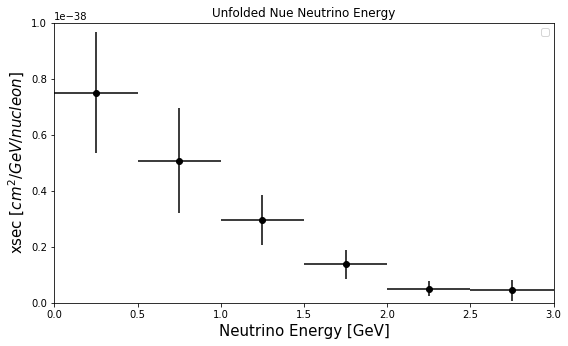

In [19]:
import random
import numpy
from matplotlib import pyplot



nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([0, 3])    
current_bincenters =  np.arange(0.25, 3.25, 0.5)
current_bin_size = 0.5

nue_ax1.errorbar(
            current_bincenters,
            xsec_nue_events,
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            fmt='ko')

plt.title("Unfolded Nue Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('xsec $[cm^2 / GeV / nucleon]$', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 10E-39)


nue_fig.savefig("unfolded_MC_nue_"+ending+".svg",bbox_inches='tight' )

No handles with labels found to put in legend.


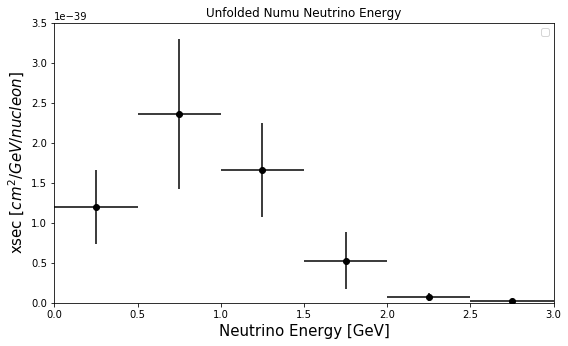

In [20]:
import random
import numpy
from matplotlib import pyplot

numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([0, 3])    #TrueE, lepton mom
current_bincenters =  np.arange(0.25, 3.25, 0.5)
current_bin_size = 0.5

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            fmt='ko')

plt.title("Unfolded Numu Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('xsec $[cm^2 / GeV / nucleon]$', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 3.5E-39)


numu_fig.savefig("unfolded_MC_numu_"+ending+".svg",bbox_inches='tight' )

No handles with labels found to put in legend.


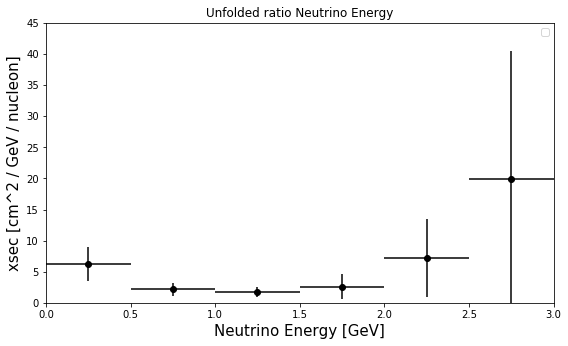

In [21]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

ratio_ax1.set_xlim([0, 3])    #TrueE, lepton mom
current_bincenters =  np.arange(0.25, 3.25, 0.5)
current_bin_size = 0.5

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            fmt='ko')

plt.title("Unfolded ratio Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('xsec [cm^2 / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 45)


ratio_fig.savefig("unfolded_MC_ratio_"+ending+".svg",bbox_inches='tight' )

In [22]:
nue_frac_err = xsec_nue_errs/xsec_nue_events
numu_frac_err = xsec_numu_errs/xsec_numu_events
ratio_frac_err = xsec_ratio_errs/xsec_ratio_events

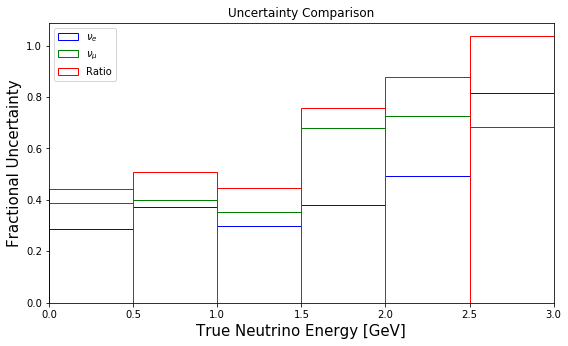

In [23]:
errors_fig = plt.figure(figsize=(8, 7))
errors_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
errors_ax1 = plt.subplot(ratio_gs[0])
errors_ax1.set_xlim([0, 3]) 

bins = np.arange(0, 3.5, 0.5)
count = np.arange(0.1, 3.1, 0.5)
#plt.ylim(0, 1)

sel_nue = errors_ax1.hist(count, bins, edgecolor='blue', facecolor='None', weights=nue_frac_err, label='$\\nu_{e}$')
sel_numu = errors_ax1.hist(count, bins, edgecolor='green', facecolor='None', weights=numu_frac_err, label='$\\nu_{\\mu}$')
sel_ratio = errors_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=ratio_frac_err, label='Ratio')
errors_ax1.set_ylabel('Fractional Uncertainty', fontsize=15)
errors_ax1.set_xlabel('True Neutrino Energy [GeV]', fontsize=15)
errors_ax1.set_title("Uncertainty Comparison")
leg = errors_ax1.legend()
plt.tight_layout()


errors_fig.savefig("unfolded_MC_errors_"+ending+".svg",bbox_inches='tight' )

## Now compare the unfolded result to the GENIE prior truth x Ac

In [24]:
smeared_truth = np.dot(prior_true, chunks)
#smeared_nuWro = np.dot(prior_true_nuWro, nuWro_Ac)
print("Prior_Truth x AC: ")
print(smeared_truth)

Prior_Truth x AC: 
[ 212.11173718  446.01419262  223.89662498  117.46603163   29.45117274
   64.25945379 3494.07386127 9093.0876917  5329.96737712 2478.0292863
  344.71841763  103.93920673]


In [25]:
nue_smeared_truth = np.array(smeared_truth[0:6])
numu_smeared_truth = np.array(smeared_truth[6:12])

In [26]:
xsec_nue_smeared_truth = nue_smeared_truth / (int_flux * Narg *0.25)     
xsec_numu_smeared_truth = numu_smeared_truth / (int_flux_numu * Narg *0.25) 


xsec_ratio_smeared_truth = np.nan_to_num(xsec_nue_smeared_truth/xsec_numu_smeared_truth)
print("Ratio event counts: ", xsec_ratio_smeared_truth)

Ratio event counts:  [ 2.65757715  2.14728931  1.83897683  2.07519601  3.74017022 27.06517838]


In [27]:
bins = np.arange(0, 3.5, 0.5)
count = np.arange(0.1, 3.1, 0.5)

print(bins)
print(count)

[0.  0.5 1.  1.5 2.  2.5 3. ]
[0.1 0.6 1.1 1.6 2.1 2.6]


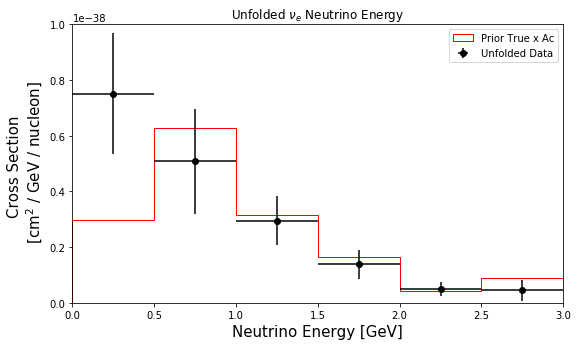

In [28]:
nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([0, 3])    
current_bincenters =  np.arange(0.25, 3.25, 0.5)
current_bin_size = 0.5

nue_ax1.errorbar(
            current_bincenters,
            xsec_nue_events,
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_nue = nue_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_nue_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded $\\nu_{e}$ Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('Cross Section \n [cm$^2$ / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 10E-39)

nue_fig.savefig("unfolded_MC_nue_comp_"+ending+".svg",bbox_inches='tight' )

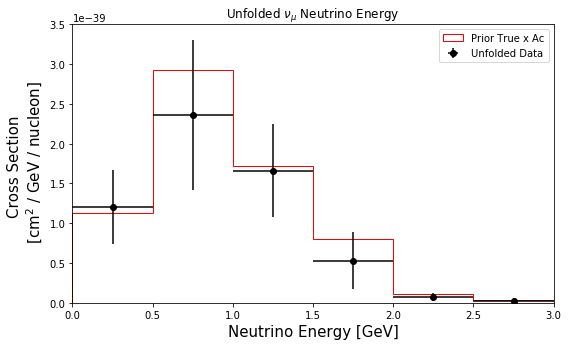

In [29]:
numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([0, 3])    #TrueE, lepton mom
current_bincenters =  np.arange(0.25, 3.25, 0.5)
current_bin_size = 0.5

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_numu = numu_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_numu_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded $\\nu_{\\mu}$ Neutrino Energy")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('Cross Section \n [cm$^2$ / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 3.5E-39)

numu_fig.savefig("unfolded_MC_numu_comp_"+ending+".svg",bbox_inches='tight' )

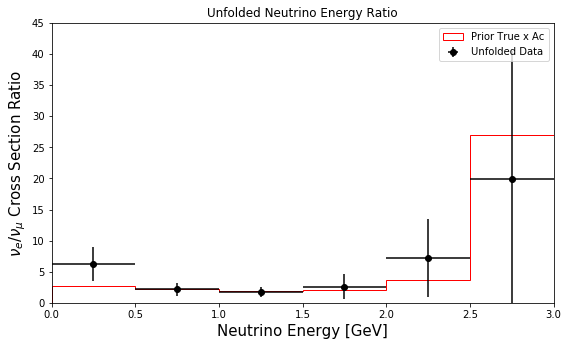

In [31]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

ratio_ax1.set_xlim([0, 3])    #TrueE, lepton mom
current_bincenters =  np.arange(0.25, 3.25, 0.5)
current_bin_size = 0.5

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_ratio = ratio_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_ratio_smeared_truth, label='Prior True x Ac', histtype="step")


plt.title("Unfolded Neutrino Energy Ratio")
plt.xlabel("Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('$\\nu_{e}$/$\\nu_{\\mu}$ Cross Section Ratio', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 45)

ratio_fig.savefig("unfolded_MC_ratio_comp_"+ending+".svg",bbox_inches='tight' )

## Some Chi2 Tests

In [39]:
#NUE

import scipy.stats as sp

f_obs_nue = xsec_nue_events
f_exp_nue = f_exp_nue[0]

print(f_obs_nue)
print(f_exp_nue)

[7.51451003e-39 5.08327421e-39 2.95371646e-39 1.37629605e-39
 5.10318333e-40 4.42402045e-40]
[2.98653324e-39 6.27987979e-39 3.15246446e-39 1.65392171e-39
 4.14672509e-40 9.04773103e-40]


In [40]:
inverse_unfcov_nue = np.linalg.inv(nue_errs_bot)

In [41]:
chi2_genie_nue = 0

print(len(bins)-1)
print(len(f_obs_nue))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_nue)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_nue = chi2_genie_nue  + ( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov_nue[i][j]*(f_obs_nue[j]-f_exp_nue[j]) )

6
6


In [42]:
chi2_genie_nue

5.328152938735002

In [43]:
#NUMU

f_obs_numu = xsec_numu_events
f_exp_numu = f_exp_numu[0]

print(f_obs_numu)
print(f_exp_numu)

[1.19980807e-39 2.36437893e-39 1.66278360e-39 5.28239618e-40
 7.13405389e-41 2.22032001e-41]
[1.12378045e-39 2.92456157e-39 1.71424914e-39 7.96995418e-40
 1.10869957e-40 3.34294159e-41]


In [44]:
inverse_unfcov_numu = np.linalg.inv(numu_errs_top)

In [45]:
chi2_genie_numu = 0

print(len(bins)-1)
print(len(f_obs_numu))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_numu)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_numu = chi2_genie_numu  + ( (f_obs_numu[i]-f_exp_numu[i])*inverse_unfcov_numu[i][j]*(f_obs_numu[j]-f_exp_numu[j]) )

6
6


In [46]:
chi2_genie_numu

1.291625179709854

In [47]:
#RATIO

f_obs_ratio = xsec_ratio_events
f_exp_ratio = f_exp_ratio[0]

print(f_obs_ratio)
print(f_exp_ratio)

[ 6.26309344  2.14994058  1.77636853  2.60543891  7.15327275 19.92514783]
[ 2.65757715  2.14728931  1.83897683  2.07519601  3.74017022 27.06517838]


In [48]:
nue_term = (nue_errs_bot)/(xsec_nue_events*xsec_nue_events)
#print("nue: ", nue_term)
#print("")
numu_term = (numu_errs_top)/(xsec_numu_events*xsec_numu_events)
#print("numu: ", numu_term)
#print("")
mix_1 = (mix_errs_bot)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_1)
#print("")
mix_2 = (mix_errs_top)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_2)
#print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
print(np.sqrt(np.diag(ratio_var_errs)))

[[ 7.67696156e+00  7.70048086e-02  2.81919772e-01  5.70876055e-01
   7.91968513e+01  1.34765765e+03]
 [ 2.32302386e+00  1.19229524e+00  9.08878348e-01  7.36002247e+00
   3.01602247e+02  6.43134606e+03]
 [ 3.55050399e+00  5.48965102e-01  6.27721572e-01  1.33370449e+00
   3.78379751e+01  4.50522829e+02]
 [ 8.76511199e-01  2.94716185e-01  1.21172077e-01  3.88168566e+00
   1.94264984e+02  4.34511846e+03]
 [ 2.37178408e-01  3.37239525e-02  2.85806981e-02  6.18203343e-01
   3.95852924e+01  5.57513872e+02]
 [-5.70050338e-02  1.01540204e-01  8.07938632e-02  5.49609363e-01
   3.29332820e+00  4.25974619e+02]]
[ 2.77073304  1.09192273  0.79228882  1.9701994   6.29168439 20.63915257]


In [49]:
inverse_unfcov_ratio = np.linalg.inv(ratio_var_errs)

In [50]:
chi2_genie_ratio = 0

print(len(bins)-1)
print(len(f_obs_ratio))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_ratio)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_ratio = chi2_genie_ratio  + ( (f_obs_ratio[i]-f_exp_ratio[i])*inverse_unfcov_ratio[i][j]*(f_obs_ratio[j]-f_exp_ratio[j]) )

6
6


In [51]:
chi2_genie_ratio

-12.34911376429106